# Transfer Learning — Clasificación de Enfermedades en Hojas de Mango

Modelo VGG-16 preentrenado en ImageNet, ajustado (fine-tuned) sobre el conjunto de datos de enfermedades en hojas de mango.

**Modificaciones en la arquitectura:**

- Extractor de características (capas convolucionales) — congelado  
  Se mantienen fijos los pesos aprendidos en ImageNet para preservar los filtros que detectan bordes, texturas y patrones visuales generales.

- Bloque final de clasificación — reemplazado por `Dropout(0.5) + Linear(4096, num_classes)`  
  Se sustituyó la última capa completamente conectada para que la salida coincida exactamente con el número de clases del dataset.  
  Se añadió una capa Dropout con probabilidad 0.5 para reducir el sobreajuste, desactivando aleatoriamente neuronas durante el entrenamiento y mejorando la capacidad de generalización del modelo.

## 1. Importaciones y pruebas de sistema

In [ ]:
import sys
from pathlib import Path

import torch

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.dataset import get_dataloaders
from src.model import build_vgg16
from src.train import train_model
from src.evaluate import evaluate_model
from src.utils import set_seed, plot_training_curves, plot_confusion_matrix

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")
print(f"Project root: {ROOT}")
set_seed(42)

Using device: mps
Project root: /Users/diego/Uvg/VisionPorComputadora/ExamenCorto1


## 2. Data — Descarga y carga

In [4]:
import kagglehub

kaggle_path = kagglehub.dataset_download("aryashah2k/mango-leaf-disease-dataset")
print(f"Dataset path: {kaggle_path}")

100%|██████████| 103M/103M [00:20<00:00, 5.26MB/s] 

Extracting files...


Dataset path: /Users/diego/.cache/kagglehub/datasets/aryashah2k/mango-leaf-disease-dataset/versions/1


In [8]:
DATA_DIR = kaggle_path  # downloaded by kagglehub above

train_loader, val_loader, class_names, num_classes = get_dataloaders(
    data_dir=DATA_DIR,
    batch_size=32,
    num_workers=2,
)

print(f"Classes ({num_classes}): {class_names}")
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

Classes (8): ['Anthracnose', 'Bacterial Canker', 'Cutting Weevil', 'Die Back', 'Gall Midge', 'Healthy', 'Powdery Mildew', 'Sooty Mould']
Train batches: 100 | Val batches: 25


## 3. Modelo — VGG-16 Adaptado

In [9]:
model = build_vgg16(num_classes=num_classes)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /Users/diego/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:24<00:00, 22.8MB/s] 


Trainable params: 119,578,632 / 134,293,320 (89.0%)


## 4. Entrenamiento

In [10]:
EPOCHS = 10
OUTPUT_DIR = str(ROOT / "outputs" / "models")

history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    epochs=EPOCHS,
    output_dir=OUTPUT_DIR,
)

Epoch [  1/10] train_loss=1.5864  train_acc=0.4975  val_loss=0.4578  val_acc=0.9025
  -> Best model saved (val_acc=0.9025)
Epoch [  2/10] train_loss=1.0114  train_acc=0.7397  val_loss=0.0692  val_acc=0.9750
  -> Best model saved (val_acc=0.9750)
Epoch [  3/10] train_loss=1.0694  train_acc=0.7616  val_loss=0.1385  val_acc=0.9563
Epoch [  4/10] train_loss=1.0647  train_acc=0.7791  val_loss=0.0666  val_acc=0.9800
  -> Best model saved (val_acc=0.9800)
Epoch [  5/10] train_loss=0.9762  train_acc=0.8053  val_loss=0.1123  val_acc=0.9738
Epoch [  6/10] train_loss=1.1169  train_acc=0.8003  val_loss=0.0949  val_acc=0.9725
Epoch [  7/10] train_loss=1.1331  train_acc=0.8019  val_loss=0.0603  val_acc=0.9850
  -> Best model saved (val_acc=0.9850)
Epoch [  8/10] train_loss=1.1135  train_acc=0.7953  val_loss=0.0542  val_acc=0.9850
Epoch [  9/10] train_loss=0.8910  train_acc=0.8184  val_loss=0.0307  val_acc=0.9850
Epoch [ 10/10] train_loss=0.8034  train_acc=0.8316  val_loss=0.2205  val_acc=0.9637


## 5. Curvas de entrenamiento

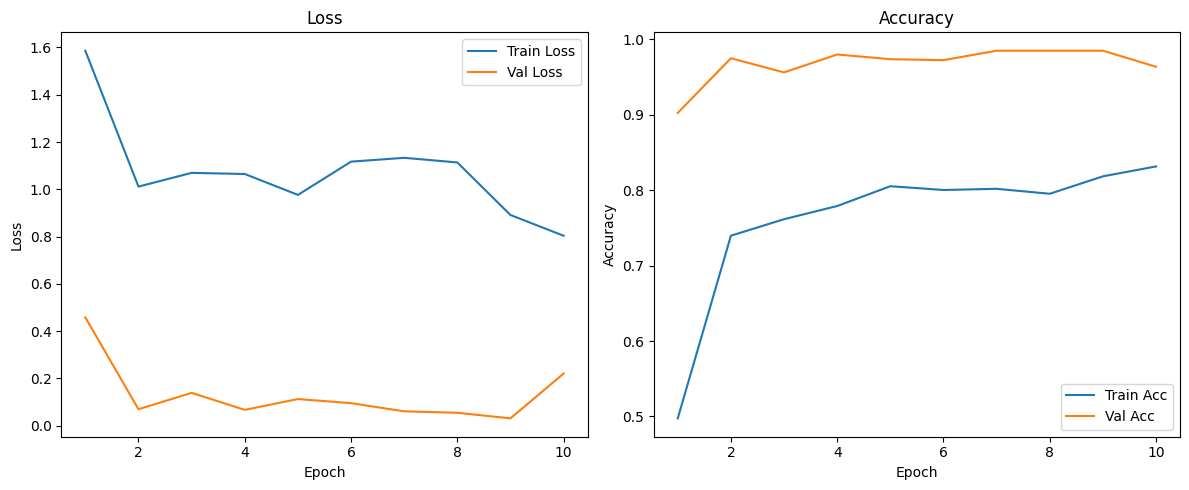

In [11]:
curves_path = str(ROOT / "outputs" / "figures" / "training_curves.png")
plot_training_curves(history, save_path=curves_path)

## 6. Evaluación

In [12]:
best_ckpt = ROOT / "outputs" / "models" / "best_model.pth"
model.load_state_dict(torch.load(str(best_ckpt), map_location=device))

y_true, y_pred, accuracy, conf_matrix = evaluate_model(model, val_loader, device)
print(f"Validation Accuracy: {accuracy*100:.2f}%")

Validation Accuracy: 98.50%


## 7. Matiz de confuisión

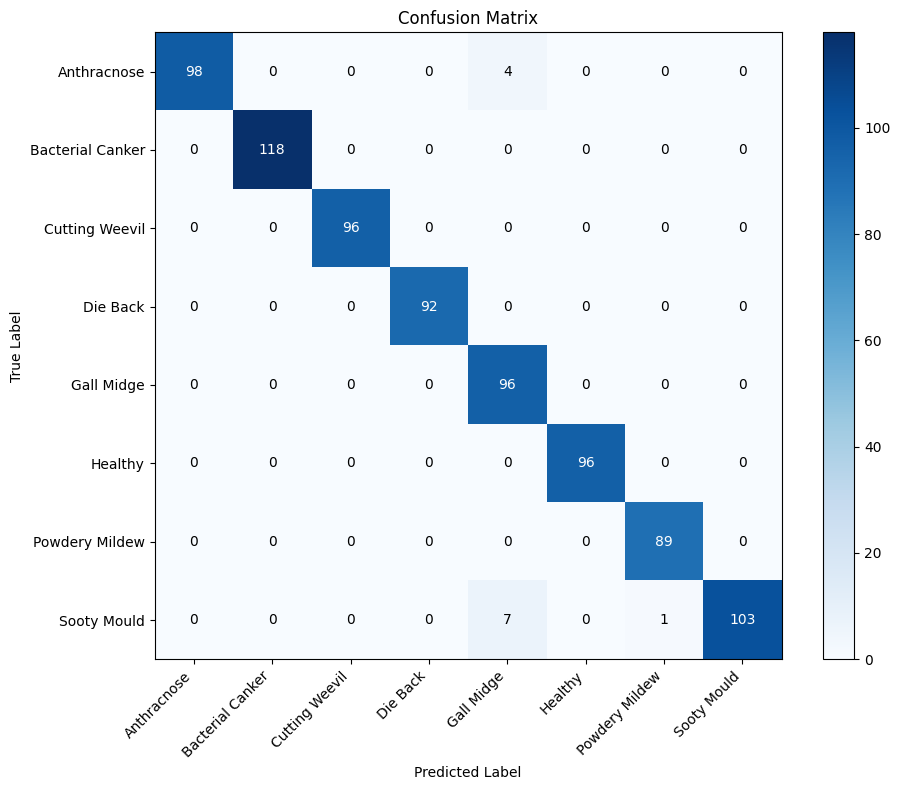

In [13]:
cm_path = str(ROOT / "outputs" / "figures" / "confusion_matrix.png")
plot_confusion_matrix(conf_matrix, class_names, save_path=cm_path)

## 8. Reporte de Resultados

### Precisión Final

El mejor modelo alcanzó una precisión de validación de **98.50%** después de 10 épocas de entrenamiento, optimizando únicamente el bloque clasificador de VGG-16 mientras se mantuvieron congeladas las capas convolucionales.  

Las curvas de entrenamiento muestran una convergencia estable: la pérdida de validación disminuye rápidamente en las primeras épocas y se mantiene baja, mientras que la precisión de validación se estabiliza cerca del 98%. No se observa divergencia significativa entre entrenamiento y validación, lo que indica buena capacidad de generalización bajo el esquema de Transfer Learning.

---

### Interpretación de la Matriz de Confusión

La matriz de confusión evidencia un desempeño altamente consistente en la mayoría de las clases, con valores predominantes en la diagonal principal (predicciones correctas).  

Las clases como *Bacterial Canker*, *Cutting Weevil*, *Die Back*, *Gall Midge*, *Healthy* y *Powdery Mildew* presentan clasificación prácticamente perfecta.  

Se observan pocos errores en:
- *Anthracnose*, con algunas predicciones confundidas con *Gall Midge*.
- *Sooty Mould*, con ligeras confusiones hacia *Gall Midge* y *Powdery Mildew*.

Estas confusiones son coherentes desde el punto de vista visual, ya que algunas enfermedades comparten patrones similares de decoloración o textura superficial. Esto sugiere que, aunque las características extraídas por VGG-16 son robustas, ciertas diferencias finas de textura pueden requerir un ajuste más profundo (fine-tuning parcial de capas convolucionales) para mejorar aún más la discriminación.

---

### Conclusión — Sobreajuste y el Rol del Dropout

Entrenar únicamente el bloque clasificador reduce significativamente el número de parámetros entrenables, disminuyendo el riesgo de sobreajuste en un dataset relativamente pequeño. La alta precisión de validación junto con una pérdida de validación estable indica que el modelo generaliza adecuadamente.

La capa `Dropout(p=0.5)` introduce regularización al desactivar aleatoriamente el 50% de las activaciones durante el entrenamiento, evitando la co-adaptación excesiva de neuronas y funcionando como un ensamblado implícito de submodelos.  

No se observa evidencia clara de sobreajuste en las curvas presentadas; sin embargo, si apareciera una brecha creciente entre pérdida de entrenamiento y validación, podría mitigarse mediante mayor aumento de datos, incremento del Dropout o descongelamiento progresivo de las últimas capas convolucionales para un ajuste fino más profundo.